In [48]:
import pandas as pd
from scipy import stats
import itertools

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = pd.read_parquet('./data/dataset.parquet')

In [9]:
data.columns

Index(['cv', 'letter', 'presentation', 'cv_phd_1', 'cv_phd_2', 'letter_phd_1',
       'letter_phd_2', 'pres_phd_1', 'pres_phd_2', 'pres_class', 'video_phd_1',
       'video_phd_2', 'all_phd_1', 'all_phd_2', 'final_human_score',
       'prof_score', 'offline_test_1', 'offline_test_2', 'offline_test_3',
       'offline_test_4', 'offline_test_total', 'online_test_score',
       'project_participation_flag', 'school_participation_flag',
       'project_ta_score', 'project_peer_score'],
      dtype='object')

In [23]:
data_subset = data[['cv_phd_1', 'cv_phd_2', 'letter_phd_1',
       'letter_phd_2', 'pres_phd_1', 'pres_phd_2', 'pres_class', 'video_phd_1',
       'video_phd_2', 'all_phd_1', 'all_phd_2',
       'prof_score', 'online_test_score','offline_test_total',
       'project_participation_flag', 'school_participation_flag',
       'project_ta_score', 'project_peer_score']]

data_subset.head()

,cv_phd_1,cv_phd_2,letter_phd_1,letter_phd_2,pres_phd_1,pres_phd_2,pres_class,video_phd_1,video_phd_2,all_phd_1,all_phd_2,prof_score,online_test_score,offline_test_total,project_participation_flag,school_participation_flag,project_ta_score,project_peer_score
name,,,,,,,,,,,,,,,,,,
Adam Mazilescu,3.25,3.0,3.50,4.75,7.00,8.00,2.0,20.0,20.0,75.0,83.0,NaN,55.0,NaN,True,True,3.0,9.5
Adam Wieloch,4.00,3.5,3.25,4.25,5.75,6.25,3.0,20.0,20.0,72.0,76.0,NaN,0.0,NaN,False,True,NaN,NaN
Adi Cristea,4.50,4.0,4.50,5.00,8.50,8.75,2.0,15.0,15.0,85.0,86.0,5.0,58.0,NaN,True,True,4.0,9.5
Adolf Spieß .,2.75,3.0,5.00,4.50,7.50,8.00,2.0,20.0,20.0,81.0,82.0,NaN,0.0,NaN,False,True,NaN,NaN
Adrián Labuda,3.25,2.5,4.25,4.25,7.50,7.25,2.0,20.0,20.0,80.0,76.0,NaN,0.0,NaN,False,True,NaN,NaN


In [31]:
data_subset = data_subset[data_subset.prof_score > 0]

In [32]:
def clean_df(df):
    df = df.copy()
    # Fill NaN with 0
    df = df.fillna(0)
    # Convert all boolean columns to int
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)
    return df

# Usage
df_clean = clean_df(data_subset)

In [33]:
df_clean.columns, df_clean.shape

(Index(['cv_phd_1', 'cv_phd_2', 'letter_phd_1', 'letter_phd_2', 'pres_phd_1',
        'pres_phd_2', 'pres_class', 'video_phd_1', 'video_phd_2', 'all_phd_1',
        'all_phd_2', 'prof_score', 'online_test_score', 'offline_test_total',
        'project_participation_flag', 'school_participation_flag',
        'project_ta_score', 'project_peer_score'],
       dtype='object'),
 (98, 18))

In [34]:
student_results = df_clean[['online_test_score', 'school_participation_flag',
       'project_ta_score','offline_test_total', 'project_peer_score']]

student_results['test_score'] = student_results['online_test_score'] +  student_results['offline_test_total']

student_results[['test_score', 'school_participation_flag',
       'project_ta_score', 'project_peer_score']]

/tmp/ipykernel_37863/422462432.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_results['test_score'] = student_results['online_test_score'] +  student_results['offline_test_total']


,test_score,school_participation_flag,project_ta_score,project_peer_score
name,,,,
Adi Cristea,58.000000,1,4.0,9.50
Agata Trüb,1.800957,0,3.0,8.30
Agáta Králová,0.000000,1,0.0,0.00
Aleš Martin,0.000000,0,0.0,0.00
Alfréd Majeský,61.000000,1,3.0,8.00
...,...,...,...,...
Zina Hošťáková,2.141353,0,3.0,9.00
Ľubomír Samel,2.649522,0,4.0,8.25
Ľubor Franko CSc.,0.000000,1,0.0,0.00


<Axes: >

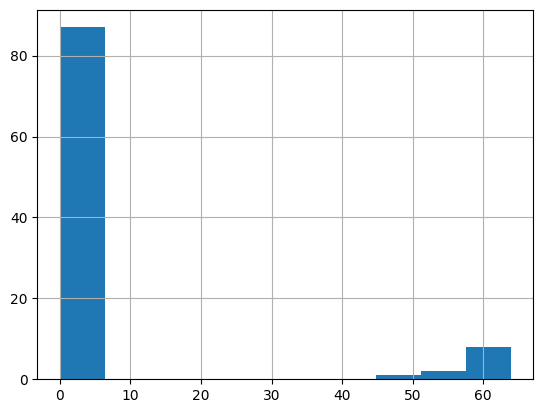

In [35]:
student_results['test_score'].hist()

In [39]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(student_results)

pca = PCA(n_components=1)  # We only want the first component
first_component = pca.fit_transform(scaled_data)

# Add as a new feature to the original DataFrame
student_results['PCA_Component_1'] = first_component

print("\nFinal DataFrame with PCA component:")
student_results.head()


Final DataFrame with PCA component:


/tmp/ipykernel_37863/1098245832.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_results['PCA_Component_1'] = first_component


,online_test_score,school_participation_flag,project_ta_score,offline_test_total,project_peer_score,test_score,PCA_Component_1
name,,,,,,,
Adi Cristea,58.0,1,4.0,0.000000,9.5,58.000000,1.872393
Agata Trüb,0.0,0,3.0,1.800957,8.3,1.800957,1.420847
Agáta Králová,0.0,1,0.0,0.000000,0.0,0.000000,-2.334627
Aleš Martin,0.0,0,0.0,0.000000,0.0,0.000000,-1.574288
Alfréd Majeský,61.0,1,3.0,0.000000,8.0,61.000000,1.369391


In [40]:
data_profs_only = data = data[data.prof_score > 0]

data_profs_only = clean_df(data_profs_only)

In [43]:
df_clean['test_score'] = student_results['test_score']
df_clean['PCA_score'] = first_component

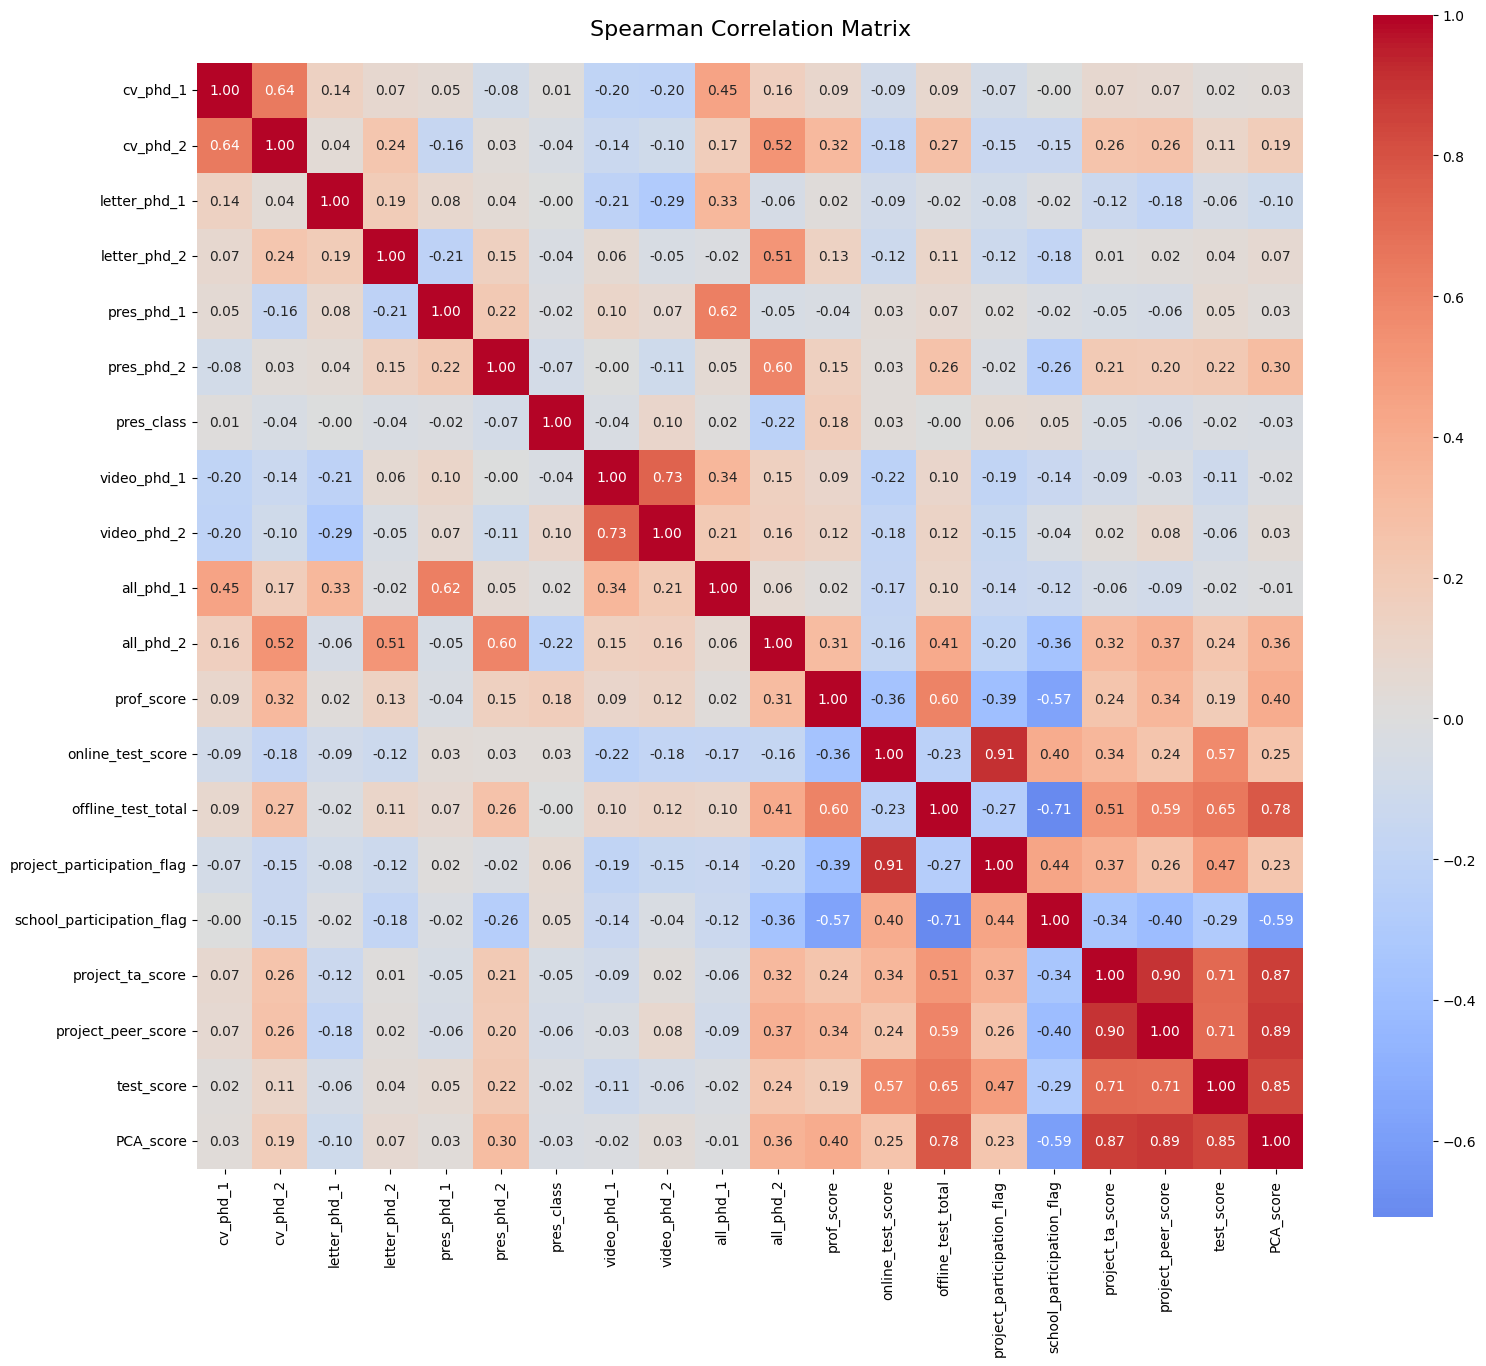

In [50]:
# Compute Spearman correlation (rank-based)
corr_matrix = df_clean.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(16, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', 
            cbar_kws={"shrink": .8})
plt.title("Spearman Correlation Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()